# Import libraries

In [1]:
import kagglehub
import shutil
import itertools
import pandas as pd
import numpy as np
from IPython.display import HTML, display

import plotly.graph_objects as go

# Utility functions

In [2]:
def base_information(data):
    df = pd.DataFrame(data.dtypes, columns=['dtypes'])
    df['Number of missing values'] = data.isna().sum()
    df['Percentage of missing values'] = data.isna().sum() / data.shape[0] * 100
    df['Unique values'] = data.nunique().values
    df['Count'] = data.count().values
    df = df.reset_index().rename(columns={'index': 'Column'})
    styled_df = (
        df
        .style
        .set_caption("📝 Base Information")
        .format({
            'Number of missing values': '{:,.0f}',
            'Percentage of missing values': '{:.2f}%',
            'Unique values': '{:,.0f}',
            'Count': '{:,.0f}'
        })
        .bar(subset=['Percentage of missing values'], color='#4a90e2', vmin=0, vmax=100)
        .set_properties(**{
            'text-align': 'left',
            'font-family': 'Times New Roman',
            'font-size': '1.25em',  # Increased font size for cell content
            'background-color':  '#f9f9f9',
            'border': '1px solid #ddd',
            'color': '#333'
        })
        .set_table_styles([{'selector': 'th','props': [('font-weight', 'bold'), ('border', '1px solid #ddd')]}])
    )
    return styled_df

def initial_columns_removal(df: pd.DataFrame) -> pd.DataFrame:
    """
    Remove features that are not useful for the model:
        - 1 unique value (variance = 0)
        - all missing values
        - duplicated columns
    
    Args:
        df (pd.DataFrame): DataFrame to be cleaned.
    
    Returns:
        pd.DataFrame: Cleaned DataFrame.
    """
    number_of_columns_before = df.shape[1]

    # Remove columns with only 1 unique value
    nunique_mask = df.nunique() > 1
    single_unique_cols = df.columns[~nunique_mask].tolist()
    if single_unique_cols:
        print(f"Removed columns with only 1 unique value: {single_unique_cols}")
    df = df.loc[:, nunique_mask]

    # Remove columns with all missing values
    na_mask = ~df.isna().all()
    all_na_cols = df.columns[~na_mask].tolist()
    if all_na_cols:
        print(f"Removed columns with all missing values: {all_na_cols}")
    df = df.loc[:, na_mask]

    # Remove duplicated columns
    duplicated_mask = ~df.columns.duplicated()
    duplicated_cols = df.columns[~duplicated_mask].tolist()
    if duplicated_cols:
        print(f"Removed duplicated columns: {duplicated_cols}")
    df = df.loc[:, duplicated_mask]

    print(f"Total columns removed: {number_of_columns_before - df.shape[1]}")
    return df.reset_index(drop=True)

def get_categorical_columns(df: pd.DataFrame) -> list[str]:
    """
    Get categorical columns from the DataFrame.

    Args:
        df (pd.DataFrame): The input DataFrame.
    
    Returns:
        list[str]: List of categorical columns.
    """
    categorical_columns = df.select_dtypes(include=['object', 'category']).columns
    categorical_columns = [col for col in categorical_columns if df[col].nunique() < 100]
    categorical_columns = list(set(categorical_columns) | set(df.columns[df.nunique() < 10]))
    return categorical_columns

def drop_highly_skewed_categorical_columns(df, columns_to_investigate, threshold=0.99) -> pd.DataFrame:
    """
    Show categorical columns with a distribution where one value is more than the specified threshold of the data.
    
    Args:
        data (pd.DataFrame): The input DataFrame.
        columns_to_investigate (list): List of categorical columns to investigate.
        threshold (float): The threshold for skewness in the distribution.
        
    Returns:
        pd.DataFrame: The DataFrame with highly skewed categorical columns dropped.
    """
    count = 0
    print(f"Highly skewed categorical columns with a distribution where one value is more than {threshold*100:.2f}% of the data:\n")
    for column in columns_to_investigate:
        value_counts = df[column].value_counts(normalize=True)
        if (value_counts.max() > threshold):
            print(f"  - {column} (value '{value_counts.idxmax()}' with {value_counts.max()*100:.2f}% of the data)")
            df.drop(columns=[column], axis=1, inplace=True)
            count += 1
    print(f"Number of columns after removal: {df.shape[1]}. Removed {count} columns.")
    return df

def categorize_categorical_columns_by_missing(data: pd.DataFrame, categorical_columns: list[str]) -> dict[str, list[str]]:
    """
    Categorize categorical columns in the DataFrame by their proportion of missing values.

    Args:
        data (pd.DataFrame): The input DataFrame.
        categorical_columns (list[str]): List of categorical columns.

    Returns:
        dict[str, list[str]]: Dictionary with keys as types of categorical columns and values as lists of column names.
    """
    categorical_not_many_missing_columns = [col for col in categorical_columns if 0 < data[col].isnull().mean() <= 0.1]
    categorical_many_missing_columns = [col for col in categorical_columns if data[col].isnull().mean() > 0.1]
    categorical_missing_columns = [col for col in categorical_columns if data[col].isnull().mean() > 0.0]
    non_missing_categorical_columns = [col for col in categorical_columns if data[col].isnull().mean() == 0.0]
    return  {
        "categorical_not_many_missing_columns": categorical_not_many_missing_columns,
        "categorical_many_missing_columns": categorical_many_missing_columns,
        "categorical_missing_columns": categorical_missing_columns,
        "non_missing_categorical_columns": non_missing_categorical_columns
    }

def describe_numerical_feature(data, feature):
    """
    Enhanced numerical feature analysis with styling for clear Copilot sharing.

    Args:
        data (pd.DataFrame): The input DataFrame.
        feature (str): The numerical feature to analyze.

    Returns:
        pd.DataFrame: A styled DataFrame summarizing the feature's statistics.
    """
    stats = data[feature].describe().T
    stats["5%"] = data[feature].quantile(0.05)
    stats["95%"] = data[feature].quantile(0.95)
    stats['variance'] = data[feature].var()
    stats['skewness'] = data[feature].skew()
    stats['kurtosis'] = data[feature].kurtosis()
    missing_count = data[feature].isna().sum()
    missing_pct = missing_count / len(data) * 100
    stats['missing_count'] = missing_count
    stats['missing_pct'] = missing_pct
    stats = stats.rename({
        "count": "Count",
        "mean": "Mean",
        "std": "Std",
        "min": "Min",
        "25%": "Q1",
        "50%": "Median",
        "75%": "Q3",
        "max": "Max"
    })
    stats = stats[["Count", "Mean", "Std", "Min", "5%", "Q1", "Median", "Q3", "95%", "Max", "variance", "skewness", "kurtosis", "missing_count", "missing_pct"]]
    stats_df = stats.to_frame().T

    styled_stats = (
        stats_df
        .style
        .set_caption(f"📈 {feature} Statistics")
        .format({
            'Count': '{:,.0f}',
            'Mean': '{:,.2f}',
            'Std': '{:,.2f}',
            'Min': '{:,.2f}',
            '5%': '{:,.2f}',
            'Q1': '{:,.2f}',
            'Median': '{:,.2f}',
            'Q3': '{:,.2f}',
            '95%': '{:,.2f}',
            'Max': '{:,.2f}',
            'variance': '{:,.2f}',
            'skewness': '{:,.2f}',
            'kurtosis': '{:,.2f}',
            'missing_count': '{:,.0f}',
            'missing_pct': '{:.2f}%'
        })
        .set_properties(**{
            'text-align': 'left',
            'font-family': 'Times New Roman',
            'font-size': '1.25em',  # Increased font size for cell content
            'background-color':  '#f9f9f9',
            'border': '1px solid #ddd',
            'color': '#333'
        })
        .set_table_styles([{'selector': 'th','props': [('font-weight', 'bold'),('border', '1px solid #ddd')]}])
    )
    return styled_stats

def describe_categorical_feature(data: pd.DataFrame, feature: str, top_n: int = 15) -> pd.DataFrame:
    """
    Enhanced categorical feature analysis with styling for clear Copilot sharing.

    Args:
        data (pd.DataFrame): The input DataFrame.
        feature (str): The categorical feature to analyze.
        top_n (int): The number of top categories to display.
    
    Returns:
        pd.DataFrame: A styled DataFrame summarizing the feature's distribution.
    """
    data_copy = data.copy()
    counts = data_copy[feature].value_counts()
    total = len(data_copy)
    if len(counts) > top_n:
        top_counts = counts[:top_n]
        other_count = counts[top_n:].sum()
        counts = pd.concat([top_counts, pd.Series({'Other': other_count})])

    percentages = (counts / total * 100).round(2)
    missing_count = data_copy[feature].isna().sum()
    missing_pct = (missing_count / total * 100).round(2)

    stats = pd.DataFrame({
        'Category': counts.index.tolist() + ['Missing'],
        'Count': counts.values.tolist() + [missing_count],
        'Percentage (%)': percentages.values.tolist() + [missing_pct]
    })

    styled_stats = (
        stats
        .style
        .set_caption(f"📊 {feature} Distribution")
        .format({'Count': '{:,.0f}', 'Percentage (%)': '{:.2f}%'})
        .bar(subset=['Percentage (%)'], color='#4a90e2', vmin=0, vmax=100)
        .set_properties(**{
            'text-align': 'left',
            'font-family': 'Times New Roman',
            'font-size': '1.25em',  # Increased font size for cell content
            'background-color':  '#f9f9f9',
            'border': '1px solid #ddd',
            'color': '#333'
        })
        .set_table_styles([{'selector': 'th','props': [('font-weight', 'bold'),('border', '1px solid #ddd')]}])
    )
    return styled_stats

def describe_time_series_feature(data, feature):
    data_copy = data.copy()
    data_copy.reset_index(drop=True, inplace=True)
    data_copy[feature] = pd.to_datetime(data_copy[feature])
    year_counts = data_copy[feature].dt.year.value_counts().sort_index()
    year_df = pd.DataFrame({'Year': year_counts.index, 'Count': year_counts.values})
    year_df['missing_count'] = data_copy[feature].isna().sum()
    year_df['missing_pct'] = data_copy[feature].isna().sum() / len(data_copy) * 100

    month_counts = data_copy[feature].dt.month.value_counts().sort_index()
    month_df = pd.DataFrame({'Month': month_counts.index, 'Count': month_counts.values})
    month_df['missing_count'] = data_copy[feature].isna().sum()
    month_df['missing_pct'] = data_copy[feature].isna().sum() / len(data_copy) * 100

    day_counts = data_copy[feature].dt.day.value_counts().sort_index()
    day_df = pd.DataFrame({'Day': day_counts.index, 'Count': day_counts.values})
    day_df['missing_count'] = data_copy[feature].isna().sum()
    day_df['missing_pct'] = data_copy[feature].isna().sum() / len(data_copy) * 100

    print("Year Distribution")
    display(year_df.style.background_gradient(cmap='Blues').format({"Count": "{:.0f}", "missing_count": "{:.0f}", "missing_pct": "{:.2f}"}))
    print("Month Distribution")
    display(month_df.style.background_gradient(cmap='Blues').format({"Count": "{:.0f}", "missing_count": "{:.0f}", "missing_pct": "{:.2f}"}))
    print("Day Distribution")
    display(day_df.style.background_gradient(cmap='Blues').format({"Count": "{:.0f}", "missing_count": "{:.0f}", "missing_pct": "{:.2f}"}))

In [3]:
class Plots:
    def check_data(self, data):
        if not isinstance(data, pd.DataFrame) and not isinstance(data, pd.Series) and not isinstance(data, np.ndarray):
            raise TypeError('Wrong type of data. It should be pandas DataFrame, pandas Series, numpy array')
        data = np.array(data)
        data = data[~np.isnan(data)]
        if(data.ndim == 2):
            data = data.squeeze()
        return data
    
    def heatmap(self, data, xaxis_title="", yaxis_title=""):
        values = np.array(data).T
        x_labels = list(data.index)
        y_labels = list(data.columns)
        fig = go.Figure()
        fig.add_trace(go.Heatmap(z=values, x=x_labels, y=y_labels, colorscale="blues", text=[list(map(str, i) ) for i in values], texttemplate="%{text}", showscale=True, ygap=1, xgap=1))
        fig.update_layout(template="simple_white", xaxis_title=xaxis_title, yaxis_title=yaxis_title, width=800, height=800, title=f"<b>Heatmap<b>", title_x=0.5, font=dict(family="Times New Roman", size=16, color="Black"))
        fig.show("png")

    def barplot_missing_values(self, data, features_names, name=""):
        data = self.check_data(data=data)
        fig = go.Figure()
        fig.add_trace(go.Bar(x=features_names, y=data, marker=dict(color=data, colorscale='rainbow', line=dict(color='black', width=1))))
        fig.update_layout(template="simple_white", width=max(30*len(features_names), 1600), height=max(30*len(features_names), 800), title=f"<b>Bar chart {name.title()}<b>", title_x=0.5, yaxis_title="Frequency", xaxis=dict(title="Features", showticklabels=True), font=dict(family="Times New Roman", size=16 ,color="Black"))
        fig.show("png")

plots = Plots()

# Load data from Kaggle

In [4]:
# path = kagglehub.dataset_download("bartoszpieniak/poland-cars-for-sale-dataset")
# shutil.move(path, "data")

In [5]:
data = pd.read_csv("../data/Car_sale_ads.csv")
target_feature = "Price"
data

,Index,Price,Currency,Condition,Vehicle_brand,Vehicle_model,Vehicle_version,Vehicle_generation,Production_year,Mileage_km,...,Transmission,Type,Doors_number,Colour,Origin_country,First_owner,First_registration_date,Offer_publication_date,Offer_location,Features
0,0,86200,PLN,New,Abarth,595,NaN,NaN,2021,1.0,...,Manual,small_cars,3.0,gray,NaN,NaN,NaN,04/05/2021,"ul. Jubilerska 6 - 04-190 Warszawa, Mazowiecki...",[]
1,1,43500,PLN,Used,Abarth,Other,NaN,NaN,1974,59000.0,...,Manual,coupe,2.0,silver,NaN,NaN,NaN,03/05/2021,"kanonierska12 - 04-425 Warszawa, Rembertów (Po...",[]
2,2,44900,PLN,Used,Abarth,500,NaN,NaN,2018,52000.0,...,Automatic,small_cars,3.0,silver,NaN,NaN,NaN,03/05/2021,"Warszawa, Mazowieckie, Białołęka","['ABS', 'Electric front windows', 'Drivers air..."
3,3,39900,PLN,Used,Abarth,500,NaN,NaN,2012,29000.0,...,Manual,small_cars,3.0,gray,NaN,NaN,NaN,30/04/2021,"Jaworzno, Śląskie","['ABS', 'Electric front windows', 'Drivers air..."
4,4,97900,PLN,New,Abarth,595,NaN,NaN,2021,600.0,...,Manual,small_cars,3.0,blue,NaN,NaN,NaN,30/04/2021,"ul. Gorzysława 9 - 61-057 Poznań, Nowe Miasto ...","['ABS', 'Electrically adjustable mirrors', 'Pa..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
208299,208299,39900,PLN,Used,Żuk,Other,NaN,NaN,2014,40000.0,...,Manual,small_cars,1.0,other,NaN,NaN,NaN,30/04/2021,"ul. Huzarska 12 - 47-400 Racibórz, raciborski,...",[]
208300,208300,10900,PLN,Used,Żuk,Other,NaN,NaN,1970,63518.0,...,Manual,station_wagon,4.0,other,Poland,NaN,NaN,02/05/2021,"Włocławek, Kujawsko-pomorskie",[]
208301,208301,6900,PLN,Used,Żuk,Other,NaN,NaN,1977,11880.0,...,Manual,SUV,3.0,red,NaN,NaN,11/06/1977,28/04/2021,"Złotów, złotowski, Wielkopolskie",[]
208302,208302,5700,PLN,Used,Żuk,Other,NaN,NaN,1986,100000.0,...,Manual,minivan,2.0,blue,NaN,NaN,NaN,24/04/2021,"Kraczkowa, łańcucki, Podkarpackie",[]


In [6]:
base_information(data)

,Column,dtypes,Number of missing values,Percentage of missing values,Unique values,Count
0,Index,int64,0,0.00%,"208,304","208,304"
1,Price,int64,0,0.00%,"14,142","208,304"
2,Currency,object,0,0.00%,2,"208,304"
3,Condition,object,0,0.00%,2,"208,304"
4,Vehicle_brand,object,0,0.00%,108,"208,304"
5,Vehicle_model,object,0,0.00%,"1,203","208,304"
6,Vehicle_version,object,"70,222",33.71%,"19,056","138,082"
7,Vehicle_generation,object,"60,444",29.02%,569,"147,860"
8,Production_year,int64,0,0.00%,92,"208,304"
9,Mileage_km,float64,983,0.47%,"52,007","207,321"


# Initial features cleaning

In [7]:
data = initial_columns_removal(data)

Removed columns with only 1 unique value: ['First_owner']
Total columns removed: 1


## ❌ Dropped Features

Based on the feature definitions, the following columns will be dropped:

- `Index`: This is a unique identifier for each offer and carries no predictive value.

In [8]:
features_to_drop = ['Index']
data.drop(columns=features_to_drop, inplace=True)
print(f"Dropped features: {features_to_drop}")

Dropped features: ['Index']


Remove those columns that have at least threshold (default 0.99) of values in one category (are extremely unbalanced)

In [9]:
categorical_columns = get_categorical_columns(data)
data = drop_highly_skewed_categorical_columns(data, categorical_columns, threshold=0.99)
categorical_columns = get_categorical_columns(data)

Highly skewed categorical columns with a distribution where one value is more than 99.00% of the data:

  - Currency (value 'PLN' with 99.87% of the data)
Number of columns after removal: 22. Removed 1 columns.


## Duplicates

In [10]:
print(f"Number of duplicated rows: {data.duplicated().sum()}")
data[data.duplicated(keep=False)].sort_values(by=list(data.columns)).head(10)

Number of duplicated rows: 1597


,Price,Condition,Vehicle_brand,Vehicle_model,Vehicle_version,Vehicle_generation,Production_year,Mileage_km,Power_HP,Displacement_cm3,...,Drive,Transmission,Type,Doors_number,Colour,Origin_country,First_registration_date,Offer_publication_date,Offer_location,Features
137290,999,Used,Peugeot,307,1.6 Premium,I (2001-2005),2005,304000.0,110.0,1587.0,...,Front wheels,Manual,station_wagon,5.0,violet,NaN,NaN,01/05/2021,"Świebodzin, świebodziński, Lubuskie","['ABS', 'Twilight sensor', 'Electric rear wind..."
137291,999,Used,Peugeot,307,1.6 Premium,I (2001-2005),2005,304000.0,110.0,1587.0,...,Front wheels,Manual,station_wagon,5.0,violet,NaN,NaN,01/05/2021,"Świebodzin, świebodziński, Lubuskie","['ABS', 'Twilight sensor', 'Electric rear wind..."
132527,1600,Used,Zastava,Other,NaN,NaN,1998,60000.0,60.0,1100.0,...,Front wheels,Manual,small_cars,3.0,yellow,Poland,28/05/1999,29/04/2021,"Warszawa, Mazowieckie, Mokotów",[]
208296,1600,Used,Zastava,Other,NaN,NaN,1998,60000.0,60.0,1100.0,...,Front wheels,Manual,small_cars,3.0,yellow,Poland,28/05/1999,29/04/2021,"Warszawa, Mazowieckie, Mokotów",[]
144933,1900,Used,Renault,Laguna,1.6 Concorde,I (1993-2001),2000,122905.0,107.0,1598.0,...,Front wheels,Manual,station_wagon,5.0,silver,Germany,21/03/2000,27/04/2021,"Szamotuły, szamotulski, Wielkopolskie","['ABS', 'Electrically adjustable mirrors', 'Pa..."
144934,1900,Used,Renault,Laguna,1.6 Concorde,I (1993-2001),2000,122905.0,107.0,1598.0,...,Front wheels,Manual,station_wagon,5.0,silver,Germany,21/03/2000,27/04/2021,"Szamotuły, szamotulski, Wielkopolskie","['ABS', 'Electrically adjustable mirrors', 'Pa..."
57904,2320,Used,Ford,Focus,1.6 Trend,Mk1 (1998-2004),1998,209410.0,100.0,1596.0,...,Front wheels,Manual,compact,3.0,black,Poland,14/04/1999,03/05/2021,"Białystok, Podlaskie, Centrum","['ABS', 'Drivers airbag', 'Power steering', 'C..."
57905,2320,Used,Ford,Focus,1.6 Trend,Mk1 (1998-2004),1998,209410.0,100.0,1596.0,...,Front wheels,Manual,compact,3.0,black,Poland,14/04/1999,03/05/2021,"Białystok, Podlaskie, Centrum","['ABS', 'Drivers airbag', 'Power steering', 'C..."
147427,2400,Used,Renault,Megane,II 1.5 dCi Confort Dynamique,II (2002-2008),2005,250000.0,80.0,1461.0,...,Front wheels,Manual,sedan,5.0,burgundy,NaN,NaN,27/04/2021,"Stary Brześć 23 B - 87-880 Brześć Kujawski, wł...","['ABS', 'Electrically adjustable mirrors', 'Pa..."
147428,2400,Used,Renault,Megane,II 1.5 dCi Confort Dynamique,II (2002-2008),2005,250000.0,80.0,1461.0,...,Front wheels,Manual,sedan,5.0,burgundy,NaN,NaN,27/04/2021,"Stary Brześć 23 B - 87-880 Brześć Kujawski, wł...","['ABS', 'Electrically adjustable mirrors', 'Pa..."


In [11]:
data.drop_duplicates(inplace=True)

# Missing values

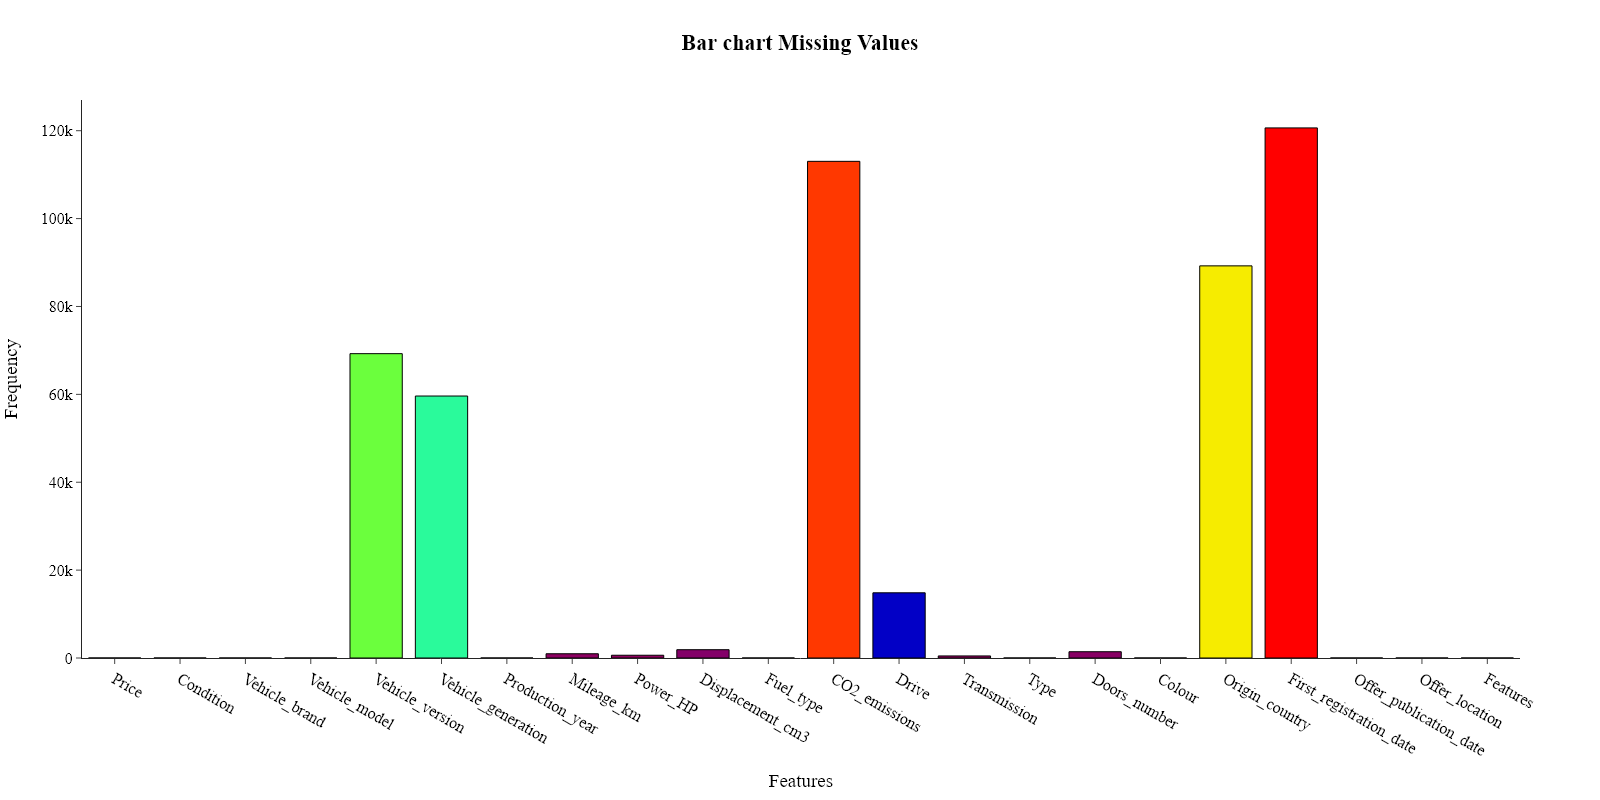

In [12]:
plots.barplot_missing_values(data.isna().sum(), data.columns, name="Missing values")

## Categorical Features

In [13]:
categorical_columns_by_missing = categorize_categorical_columns_by_missing(data, categorical_columns)

Impute missing values based on some insights from the data.

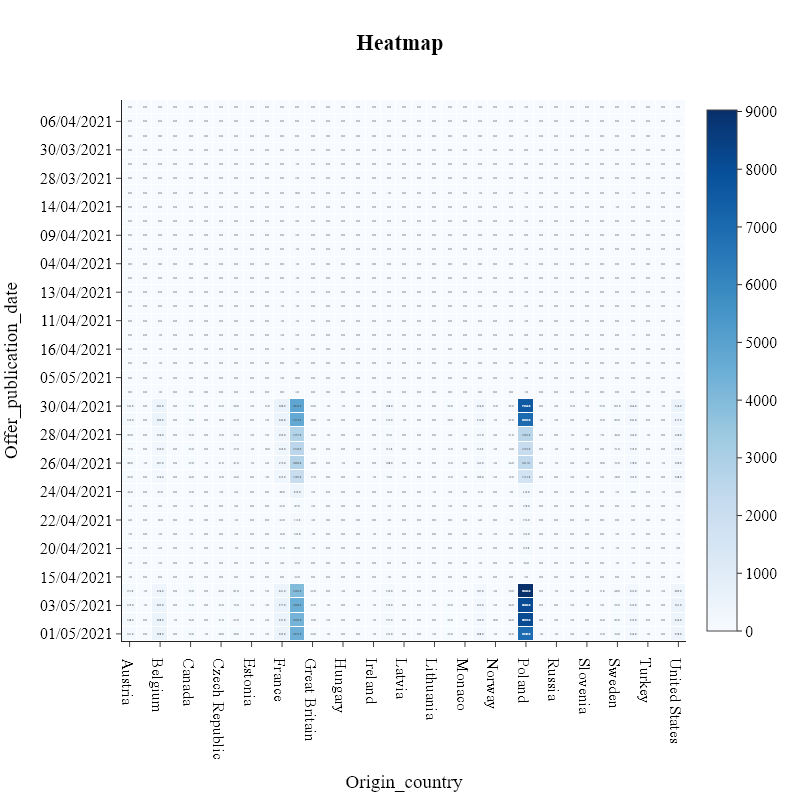

Imputed 5 rows with Germany value for column: Origin_country based on Offer_publication_date column with value: 09/04/2021.


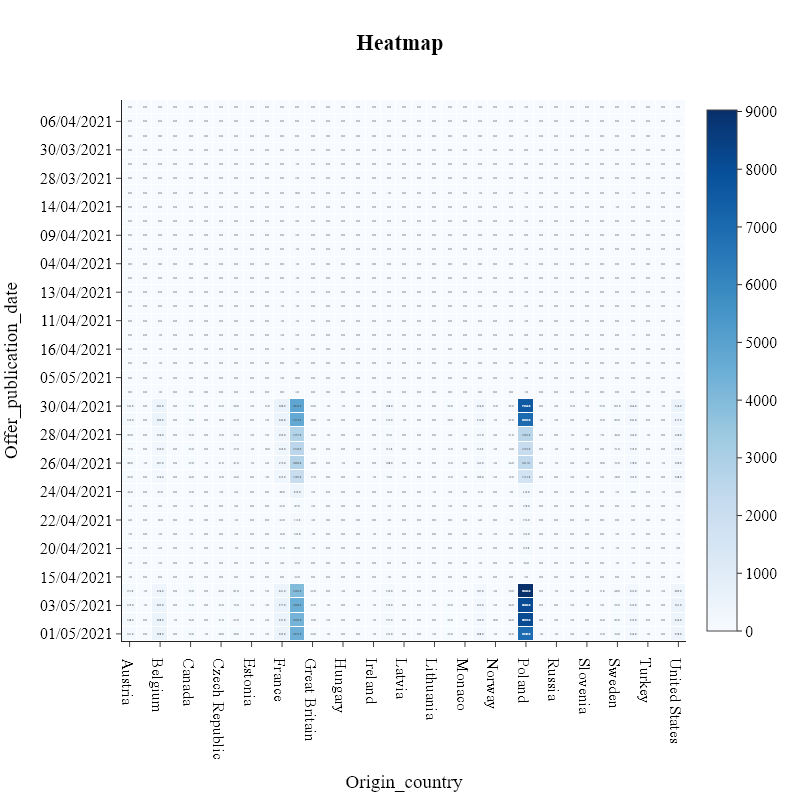

Imputed 1 rows with Poland value for column: Origin_country based on Offer_publication_date column with value: 02/04/2021.


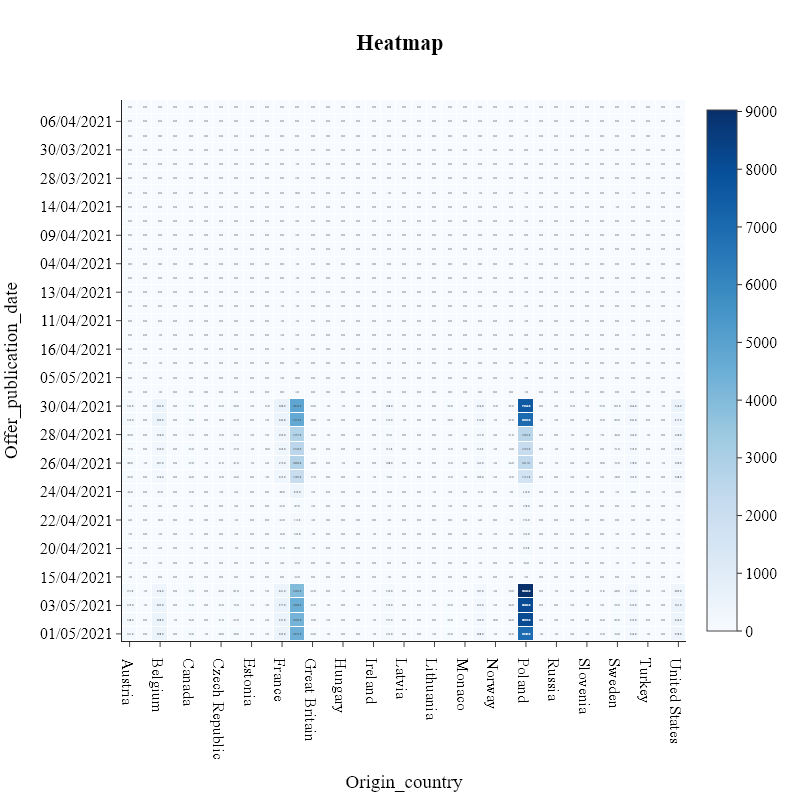

Imputed 9 rows with Poland value for column: Origin_country based on Offer_publication_date column with value: 06/04/2021.


,Price,Condition,Vehicle_brand,Vehicle_model,Vehicle_version,Vehicle_generation,Production_year,Mileage_km,Power_HP,Displacement_cm3,...,Drive,Transmission,Type,Doors_number,Colour,Origin_country,First_registration_date,Offer_publication_date,Offer_location,Features
0,86200,New,Abarth,595,NaN,NaN,2021,1.0,145.0,1400.0,...,Front wheels,Manual,small_cars,3.0,gray,NaN,NaN,04/05/2021,"ul. Jubilerska 6 - 04-190 Warszawa, Mazowiecki...",[]
1,43500,Used,Abarth,Other,NaN,NaN,1974,59000.0,75.0,1100.0,...,Front wheels,Manual,coupe,2.0,silver,NaN,NaN,03/05/2021,"kanonierska12 - 04-425 Warszawa, Rembertów (Po...",[]
2,44900,Used,Abarth,500,NaN,NaN,2018,52000.0,180.0,1368.0,...,NaN,Automatic,small_cars,3.0,silver,NaN,NaN,03/05/2021,"Warszawa, Mazowieckie, Białołęka","['ABS', 'Electric front windows', 'Drivers air..."
3,39900,Used,Abarth,500,NaN,NaN,2012,29000.0,160.0,1368.0,...,Front wheels,Manual,small_cars,3.0,gray,NaN,NaN,30/04/2021,"Jaworzno, Śląskie","['ABS', 'Electric front windows', 'Drivers air..."
4,97900,New,Abarth,595,NaN,NaN,2021,600.0,165.0,1368.0,...,NaN,Manual,small_cars,3.0,blue,NaN,NaN,30/04/2021,"ul. Gorzysława 9 - 61-057 Poznań, Nowe Miasto ...","['ABS', 'Electrically adjustable mirrors', 'Pa..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
208292,8900,Used,Zaporożec,968,NaN,NaN,1990,75148.0,50.0,1197.0,...,NaN,Manual,city_cars,2.0,red,NaN,NaN,02/05/2021,"Ogrodnicza 5-7 - 95-100 Zgierz, zgierski, Łódz...",[]
208294,1500,Used,Zastava,1100,NaN,NaN,1979,106000.0,54.0,1116.0,...,Front wheels,Manual,compact,5.0,green,NaN,NaN,29/04/2021,"Kwileń 42 - 63-313 Kwileń, pleszewski, Wielkop...",[]
208295,16999,Used,Zastava,1100,NaN,NaN,1981,62000.0,60.0,1100.0,...,NaN,Manual,coupe,3.0,green,NaN,NaN,25/04/2021,"Konstancin-Jeziorna, piaseczyński, Mazowieckie",[]
208297,19900,Used,Zastava,1100,NaN,NaN,1981,18712.0,55.0,1116.0,...,NaN,Manual,compact,4.0,beige,NaN,NaN,04/05/2021,"Szczecińska 40 - 75-137 Koszalin, Zachodniopom...",[]


In [14]:
def impute_missing_values(data, categorical_to_impute, non_missing_categorical, threshold_num_observation=10):
    """
    Impute missing values in a DataFrame based on joint distribution of categorical columns.

    Args:
        data (pd.DataFrame): The input DataFrame.
        categorical_to_impute (list): List of categorical columns with some missing values.
        non_missing_categorical (list): List of categorical columns with no missing values.
        threshold_num_observation (int): The minimum number of observations required to perform imputation.

    Returns:
        None: The function modifies the DataFrame in place.
    """
    full = [list(comb) for comb in itertools.product(categorical_to_impute, non_missing_categorical)]
    df_copy = data.copy()
    for comb in full:
        column_with_nulls = comb[0]
        column_without_nulls = comb[1]
        joint_distribution = df_copy.groupby([column_with_nulls, column_without_nulls], observed=False)[column_without_nulls].size().unstack().fillna(0)
        zero_condition = (joint_distribution[joint_distribution != 0.0].count(axis=0) == 1)
        if zero_condition.any():
            zero_value_without_nulls = zero_condition[zero_condition == True].index.tolist()
            for idx, value_without_nulls in enumerate(zero_value_without_nulls):
                number_of_observations = joint_distribution[value_without_nulls].sum()
                if(number_of_observations < threshold_num_observation):
                    #Jeśli liczba obserwacji w danej kategorii zmiennej za pomocą, której przeprowadzamy imputację jest mniejsza niż 10 to nie przeprowadzamy imputacji jest mniejsza niż threshold_num_observation to nie przeprowadzamy imputacji, ponieważ jest to zbyt mało danych aby mieć pewność, że imputacja jest poprawna
                    continue
                second_condition_rows_num = (df_copy[column_with_nulls].isnull() & (df_copy[column_without_nulls] == value_without_nulls)).sum()
                if second_condition_rows_num > 0:
                    value_to_fillna = joint_distribution[value_without_nulls][joint_distribution[value_without_nulls] != 0].index.tolist()[0]
                    plots.heatmap(data=joint_distribution, xaxis_title=column_with_nulls, yaxis_title=column_without_nulls)
                    null_rows_indices = df_copy[(df_copy[column_with_nulls].isnull()) & (df_copy[column_without_nulls] == value_without_nulls)][[column_with_nulls, column_without_nulls]].index.tolist()
                    # print(f"Rows before fillna:\n{df.loc[null_rows_indices][[column_with_nulls, column_without_nulls]].head(5)}")
                    df_copy.loc[(df_copy[column_with_nulls].isnull()) & (df_copy[column_without_nulls] == value_without_nulls), column_with_nulls] = value_to_fillna
                    # print(f"Rows after fillna:\n{df_copy.loc[null_rows_indices][[column_with_nulls, column_without_nulls]].head(5)}")
                    print(f"Imputed {len(null_rows_indices)} rows with {value_to_fillna} value for column: {column_with_nulls} based on {column_without_nulls} column with value: {value_without_nulls}.")
                #     count += 1
                # if count == 1:
                #     return df_copy
    return df_copy
impute_missing_values(data, categorical_columns_by_missing["categorical_missing_columns"], categorical_columns_by_missing["non_missing_categorical_columns"], threshold_num_observation=1)
# data = impute_missing_values(data, categorical_columns_by_missing["categorical_missing_columns"], categorical_columns_by_missing["non_missing_categorical_columns"], threshold_num_observation=1) # Only if we want to impute missing values in categorical columns

In [15]:
output = []
for col in categorical_columns_by_missing["categorical_missing_columns"]:
    output.append(describe_categorical_feature(data, col, top_n=15).to_html())
    output.append("\n")
display(HTML("<br>".join(output)))

,Category,Count,Percentage (%)
0,Poland,"56,575",27.37%
1,Germany,"38,020",18.39%
2,France,"4,839",2.34%
3,United States,"4,054",1.96%
4,Belgium,"4,040",1.95%
5,Switzerland,"2,147",1.04%
6,Netherlands,"1,790",0.87%
7,Italy,"1,379",0.67%
8,Austria,"1,213",0.59%
9,Sweden,726,0.35%


- Column name: `Drive`
- Chosen strategy: Impute with mode
- Justification: The missing rate is moderate (~7%). "Front wheels" is the dominant category (67%), so imputing with the mode is appropriate and maintains the main distribution.

In [16]:
data['Drive'] = data['Drive'].fillna(data['Drive'].mode()[0])

- Column name: `Origin_country`
- Chosen strategy: Impute with "Unknown"
- Justification: The missing rate is high (~43%), and the distribution is spread across many countries. Imputing with "Unknown" avoids biasing toward any specific country and preserves the feature's value.

In [17]:
data['Origin_country'] = data['Origin_country'].fillna('Unknown')

- Column name: `Transmission`
- Chosen strategy: Impute with mode
- Justification: The missing rate is very low (~0.2%), and "Manual" is the clear mode (64%). Imputing with the mode is safe and maintains the distribution.

In [18]:
data['Transmission'] = data['Transmission'].fillna(data['Transmission'].mode()[0])

### Convert categorical features to `category` dtype.

In [19]:
categorical_columns = get_categorical_columns(data)
for col in categorical_columns:
    data[col] = data[col].astype('category')

## Object columns

In [20]:
object_columns = data.select_dtypes(include=['object']).columns
object_missing_columns = [col for col in object_columns if data[col].isnull().mean() > 0.0]
output = []
for col in object_missing_columns:
    output.append(describe_categorical_feature(data, col, top_n=15).to_html())
    output.append("\n")
display(HTML("<br>".join(output)))

,Category,Count,Percentage (%)
0,2.0 TDI,884,0.43%
1,1.6,840,0.41%
2,Standard,645,0.31%
3,2.0 TDCi Titanium,619,0.30%
4,1.2,602,0.29%
5,1.4,600,0.29%
6,1.9 TDI,408,0.20%
7,320d,390,0.19%
8,2.0,377,0.18%
9,1.0 TSI Ambition,374,0.18%


- Column name: `Vehicle_version`
- Chosen strategy: Impute with "Unknown"
- Justification: The missing rate is high (~33.5%), and the distribution is extremely sparse with many unique values. Imputing with "Unknown" preserves the feature's information without biasing toward any specific category.

In [21]:
data['Vehicle_version'] = data['Vehicle_version'].fillna('Unknown')

- Column name: `Vehicle_generation`
- Chosen strategy: Impute with "Unknown"
- Justification: The missing rate is high (~28.8%), and the column has a very high number of unique values with no dominant category. Imputing with "Unknown" is appropriate to retain the feature for modeling.

In [22]:
data['Vehicle_generation'] = data['Vehicle_generation'].fillna('Unknown')

- Column name: `First_registration_date`
- Chosen strategy: Impute with "Unknown"
- Justification: The missing rate is very high (~58.4%), but the feature may be important for modeling. Imputing with "Unknown" allows the column to be retained for further analysis or feature engineering.

In [23]:
data['First_registration_date'] = data['First_registration_date'].fillna('Unknown')

## Numerical Features

In [24]:
numerical_columns = data.select_dtypes(include=['number']).columns
numerical_missing_columns = [col for col in numerical_columns if data[col].isnull().mean() > 0.0]
output = []
for col in numerical_missing_columns:
    output.append(describe_numerical_feature(data, col).to_html())
    output.append("\n")
display(HTML("<br>".join(output)))

,Count,Mean,Std,Min,5%,Q1,Median,Q3,95%,Max,variance,skewness,kurtosis,missing_count,missing_pct
Mileage_km,"205,740","148,372.50","2,735,028.34",1.00,3.00,"54,000.00","145,000.00","206,310.00","295,000.00","1,111,111,111.00","7,480,380,027,190.51",357.76,"137,912.42",967,0.47%
,Count,Mean,Std,Min,5%,Q1,Median,Q3,95%,Max,variance,skewness,kurtosis,missing_count,missing_pct
Power_HP,"206,079",151.86,77.57,1.00,73.00,105.00,136.00,171.00,305.00,"1,398.00","6,017.44",2.52,10.32,628,0.30%
,Count,Mean,Std,Min,5%,Q1,Median,Q3,95%,Max,variance,skewness,kurtosis,missing_count,missing_pct
Displacement_cm3,"204,815","1,882.58",727.96,400.00,999.00,"1,461.00","1,798.00","1,997.00","2,999.00","8,400.00","529,925.49",2.50,9.45,"1,892",0.92%
,Count,Mean,Std,Min,5%,Q1,Median,Q3,95%,Max,variance,skewness,kurtosis,missing_count,missing_pct
CO2_emissions,"93,677","320,416.40","73,057,811.24",1.00,99.00,120.00,140.00,164.00,222.00,"20,000,000,000.00","5,337,443,783,354,797.00",246.38,"63,698.89","113,030",54.68%
,Count,Mean,Std,Min,5%,Q1,Median,Q3,95%,Max,variance,skewness,kurtosis,missing_count,missing_pct
Doors_number,"205,277",4.64,0.77,1.00,3.00,5.00,5.00,5.00,5.00,55.00,0.59,0.76,184.76,"1,430",0.69%


- Column name: `Mileage_km`
- Chosen strategy: Impute with median
- Justification: The column is highly skewed (skewness ≈ 358), contains extreme outliers (max ≫ 95th percentile), and the missing rate is very low (~0.47%). Median imputation is robust to outliers and preserves the central tendency.

In [25]:
data['Mileage_km'] = data['Mileage_km'].fillna(data['Mileage_km'].median())

- Column name: `Power_HP`
- Chosen strategy: Impute with median
- Justification: The feature is right-skewed (skewness ≈ 2.5) with some outliers (max ≫ 95th percentile), and the missing rate is low (~0.3%). Median imputation is robust and appropriate for this distribution.

In [26]:
data['Power_HP'] = data['Power_HP'].fillna(data['Power_HP'].median())

- Column name: `Displacement_cm3`
- Chosen strategy: Impute with median
- Justification: The column is right-skewed (skewness ≈ 2.5), has outliers, and a low missing rate (~0.92%). Median imputation is robust to outliers and maintains the feature's integrity.

In [27]:
data['Displacement_cm3'] = data['Displacement_cm3'].fillna(data['Displacement_cm3'].median())

- Column name: `CO2_emissions`
- Chosen strategy: Drop column
- Justification: The missing rate is extremely high (~54.7%), and the feature contains extreme outliers (skewness ≈ 246). Imputation would not be reliable, so dropping the column is the best option.

In [28]:
data.drop(columns=['CO2_emissions'], inplace=True)

- Column name: `Doors_number`
- Chosen strategy: Impute with median
- Justification: The column is slightly right-skewed (skewness ≈ 0.76), with a very low missing rate (~0.69%). Median imputation is robust and suitable for this feature.

In [29]:
data['Doors_number'] = data['Doors_number'].fillna(data['Doors_number'].median())

## Summary

In [30]:
base_information(data)

,Column,dtypes,Number of missing values,Percentage of missing values,Unique values,Count
0,Price,int64,0,0.00%,"14,142","206,707"
1,Condition,category,0,0.00%,2,"206,707"
2,Vehicle_brand,object,0,0.00%,108,"206,707"
3,Vehicle_model,object,0,0.00%,"1,203","206,707"
4,Vehicle_version,object,0,0.00%,"19,057","206,707"
5,Vehicle_generation,object,0,0.00%,570,"206,707"
6,Production_year,int64,0,0.00%,92,"206,707"
7,Mileage_km,float64,0,0.00%,"52,007","206,707"
8,Power_HP,float64,0,0.00%,573,"206,707"
9,Displacement_cm3,float64,0,0.00%,"1,181","206,707"


# Save the cleaned dataset

In [31]:
data.to_csv("../data/data_cleaned.csv", index=False)